In [7]:
import numpy as np
import uproot
import matplotlib.pyplot as plt
import matplotlib.text

In [8]:
import sys
from atlasopenmagic import install_from_environment
install_from_environment

<function atlasopenmagic.utils.install_from_environment(*packages: str | None, environment_file: str | None = None) -> None>

In [9]:
import atlasopenmagic as atom
atom.set_release('2025e-13tev-beta')

Release '2025e-13tev-beta' already active with cached metadata.
Active release: 2025e-13tev-beta. (Datasets path: REMOTE)


In [10]:
skim = '4lep'
files_list = atom.get_urls('data', skim, protocol = 'https', cache=True)

In [11]:
# empty array to be appended to in the for loop
leps = []

for file in files_list:
    print(f'Analyzing file: {file} ({files_list.index(file)+1}/{len(files_list)})')

    # open files and turn into a structured array
    analysis = uproot.open(file +':analysis')
    attributes = ['pt','eta','phi','e','charge','flavor','tight']
    aliases_dict = {'pt':'lep_pt','eta':'lep_eta','phi':'lep_phi','e':'lep_e',
                           'charge':'lep_charge','flavor':'lep_type','tight':'lep_isTightID'}
    leps_partial = analysis.arrays(attributes, aliases = aliases_dict)

    # append the current structured array to all previous structured arrays
    leps = np.concatenate([leps,leps_partial], axis=0)
print('Completed processing all files')

Analyzing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data15_periodD.4lep.root (1/16)
Analyzing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data15_periodE.4lep.root (2/16)
Analyzing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data15_periodF.4lep.root (3/16)
Analyzing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data15_periodG.4lep.root (4/16)
Analyzing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data15_periodH.4lep.root (5/16)
Analyzing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data15_periodJ.4lep.root (6/16)
Analyzing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data16_periodA.4lep.root (7/16)
Analyzing fil

In [14]:
leps = leps[np.argsort(leps.pt, axis=1)[:,::-1]][:,:4]

px = leps.pt*np.cos(leps.phi)
py = leps.pt*np.sin(leps.phi)
pz = leps.pt*np.sinh(leps.eta)

vecs = np.array([leps.e, px, py, pz, leps.charge, leps.flavor, leps.tight])

Z0 = vecs[:,:,0] + vecs [:,:,1]
Z1 = vecs[:,:,0] + vecs [:,:,2]
Z2 = vecs[:,:,0] + vecs [:,:,3]
Z3 = vecs[:,:,1] + vecs [:,:,2]
Z4 = vecs[:,:,1] + vecs [:,:,3]
Z5 = vecs[:,:,2] + vecs [:,:,3]

Zs = np.array([Z0, Z1, Z2, Z5, Z4, Z3])

Z_charge_cut = Zs[:,4] == 0
Z_flavor_cut = (Zs[:,5] == 22) | (Zs[:,5] == 26)
Z_tight_cut = Zs[:, 6] == 2

Z_mass = np.sqrt(np.abs(Zs[:, 0, :]**2-Zs[:, 1, :]**2-Zs[:, 2, :]**2-Zs[:, 3, :]**2))

In [17]:
cut = Z_charge_cut & Z_tight_cut & Z_flavor_cut
cut_Z_mass = np.copy(Z_mass)
cut_Z_mass[~cut] = 0

Z_masses = np.ndarray.flatten(cut_Z_mass)
Z_masses = Z_masses[Z_masses != 0]

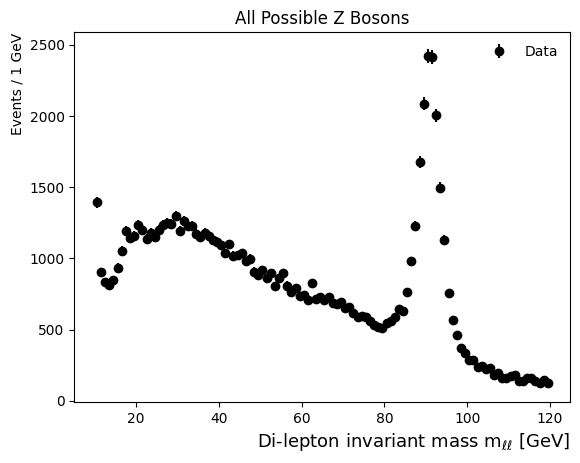

In [18]:
# x-axis range of the plot
xmin = 10 #GeV
xmax = 120 #GeV

# Histogram bin setup
bin_width = 1 #GeV
bin_edges = np.arange(start = xmin, stop = xmax + bin_width, step = bin_width)
bin_centers = bin_edges[:-1] + bin_width/2

# Creating histogram from data
counts, _ = np.histogram(Z_masses, bins = bin_edges)
count_errors = np.sqrt(counts) # poisson approximation of the error

# Plot
axs = plt.gca()
axs.errorbar(x = bin_centers, y = counts, yerr = count_errors,
                    fmt = 'ko', # 'k' means black and 'o' is for circles
                    label = 'Data')
axs.set_xlabel(r'Di-lepton invariant mass $\mathrm{m_{\ell\ell}}$ [GeV]', 
                     fontsize = 13, x = 1, horizontalalignment = 'right' )
axs.set_ylabel('Events / ' + str(bin_width) + ' GeV', y = 1, horizontalalignment = 'right')
plt.title('All Possible Z Bosons')
axs.legend(frameon = False)
plt.show()

In [19]:
Higgs = Zs[:3] + Zs[3:]

Z_mass_upper = Z_mass[:3]
Z_mass_lower = Z_mass[3:]

# define our mass constraints
Z_on_min, Z_on_max = 50, 106
Z_off_min, Z_off_max = 17.5, 115

# return true for all indices where a on\off shell pair exists
Z_up_is_on = (Z_mass_upper > Z_on_min) & (Z_mass_upper < Z_on_max)
Z_up_is_off = (Z_mass_upper > Z_off_min) & (Z_mass_upper < Z_off_max)
Z_low_is_on = (Z_mass_lower > Z_on_min) & (Z_mass_lower < Z_on_max)
Z_low_is_off = (Z_mass_lower > Z_off_min) & (Z_mass_lower < Z_off_max)

shell_cut = (Z_up_is_on & Z_low_is_off) | (Z_up_is_off & Z_low_is_on)

H_charge_cut = Z_charge_cut[:3] & Z_charge_cut[3:]
H_flavor_cut = Z_flavor_cut[:3] & Z_flavor_cut[3:]
H_tight_cut = Z_tight_cut[:3] & Z_tight_cut[3:]

H_mass = np.sqrt(np.abs(Higgs[:,0]**2-Higgs[:,1]**2-Higgs[:,2]**2-Higgs[:,3]**2))[0]

In [20]:
# choose cuts
cut = shell_cut & H_charge_cut & H_flavor_cut & H_tight_cut
# apply cuts
cut = cut[0] | cut[1] | cut[2]
H_mass = H_mass[cut]

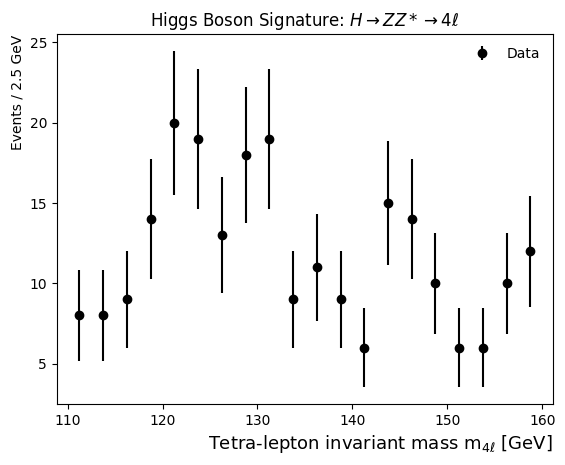

In [21]:
# x-axis range of the plot
xmin = 110 #GeV
xmax = 160 #GeV

# Histogram bin setup
bin_width = 2.5 #GeV
bin_edges = np.arange(start = xmin, stop = xmax + bin_width, step = bin_width)
bin_centers = bin_edges[:-1] + bin_width/2

# Creating histogram from data
counts, _ = np.histogram(H_mass, bins = bin_edges)
count_errors = np.sqrt(counts) # poisson approximation of the error

# Plot
axs = plt.gca()
axs.errorbar(x = bin_centers, y = counts, yerr = count_errors,
                    fmt = 'ko', # 'k' means black and 'o' is for circles
                    label = 'Data')
axs.set_xlabel(r'Tetra-lepton invariant mass $\mathrm{m_{4\ell}}$ [GeV]', 
                     fontsize = 13, x = 1, horizontalalignment = 'right' )
axs.set_ylabel('Events / ' + str(bin_width) + ' GeV', y = 1, horizontalalignment = 'right')
plt.title('Higgs Boson Signature: ' + r'$H \rightarrow ZZ* \rightarrow 4\ell$')
axs.legend(frameon = False)
plt.show()